# Data Preparation: MNIST + Fashion-MNIST

- **MNIST** (handwritten digits) — "normal" data for training the autoencoder
- **Fashion-MNIST** (clothing items) — "anomaly" data for the anomaly detection experiment

Both are 28×28 grayscale and downloaded automatically by `torchvision`.

In [1]:
from torchvision import datasets, transforms

DATA_DIR = "data"
to_tensor = transforms.ToTensor()

mnist_train = datasets.MNIST(DATA_DIR, train=True, download=True, transform=to_tensor)
mnist_test = datasets.MNIST(DATA_DIR, train=False, download=True, transform=to_tensor)
fashion_test = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=to_tensor)

print(f"MNIST train:         {len(mnist_train)} images")
print(f"MNIST test:          {len(mnist_test)} images")
print(f"Fashion-MNIST test:  {len(fashion_test)} images")
print(f"Image shape:         {mnist_train[0][0].shape}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 783kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.39MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.77MB/s]

MNIST train:         60000 images
MNIST test:          10000 images
Fashion-MNIST test:  10000 images
Image shape:         torch.Size([1, 28, 28])


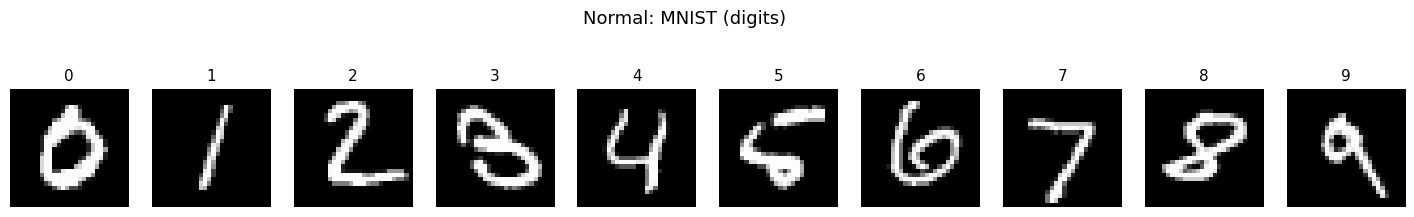

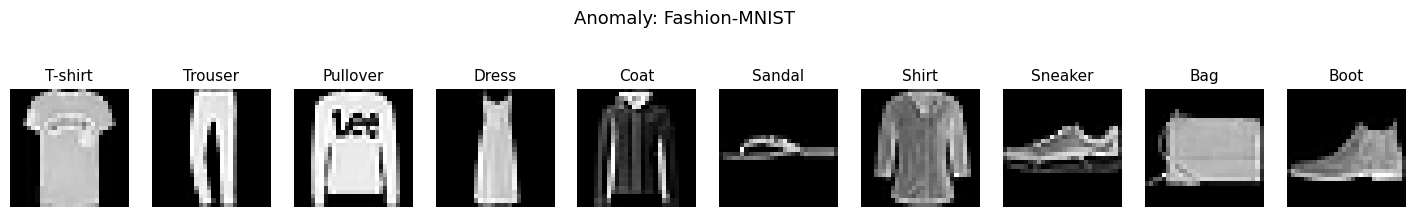

In [2]:
import matplotlib.pyplot as plt

fashion_classes = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                    "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]

# Figures for MNIST and Fashion-MNIST
for title, ds, labels in [("Normal: MNIST (digits)", mnist_test, [str(i) for i in range(10)]),
                            ("Anomaly: Fashion-MNIST", fashion_test, fashion_classes)]:
    fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
    for cls in range(10):
        idx = next(i for i, (_, y) in enumerate(ds) if y == cls)
        axes[cls].imshow(ds[idx][0].squeeze(), cmap='gray')
        axes[cls].set_title(labels[cls], fontsize=11)
        axes[cls].axis('off')
    fig.suptitle(title, fontsize=13, y=1.05)
    plt.show()